In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
import os
import missingno as msno
warnings.filterwarnings('ignore')


# Preprocessing

## Kaggle dataset

**Ref:** https://www.kaggle.com/datasets/muhammadtalhaawan/world-export-and-import-dataset?select=34_years_world_export_import_dataset.csv

In [3]:
kg_df = pd.read_csv(r"D:\university\yr3, hk1\DS111 - phân tích dữ liệu\Do_an\DS111\Data\Bronze\kaggle\34_years_world_export_import_dataset.csv")
kg_df.head()

,Partner Name,Year,Export (US$ Thousand),Import (US$ Thousand),Export Product Share (%),Import Product Share (%),Revealed comparative advantage,World Growth (%),Country Growth (%),AHS Simple Average (%),...,MFN Total Tariff Lines,MFN Dutiable Tariff Lines Share (%),MFN Duty Free Tariff Lines Share (%),MFN Specific Tariff Lines Share (%),MFN AVE Tariff Lines Share (%),MFN MaxRate (%),MFN MinRate (%),MFN SpecificDuty Imports (US$ Thousand),MFN Dutiable Imports (US$ Thousand),MFN Duty Free Imports (US$ Thousand)
0,Aruba,1988,3498.10,328.49,100.0,100,NaN,NaN,NaN,2.80,...,1152.0,63.54,22.74,70.32,31.61,352.69,0.0,2186.00,3128.02,0.0
1,Afghanistan,1988,213030.40,54459.52,100.0,100,NaN,NaN,NaN,0.88,...,4142.0,69.41,15.64,72.45,40.51,2029.66,0.0,78436.91,94191.50,0.0
2,Angola,1988,375527.89,370702.76,100.0,100,NaN,NaN,NaN,2.02,...,5438.0,76.00,16.27,41.55,24.80,451.15,0.0,727741.99,921481.52,0.0
3,Anguila,1988,366.98,4.00,100.0,100,NaN,NaN,NaN,3.71,...,322.0,66.15,22.05,78.79,36.36,100.00,0.0,94.00,583.00,0.0
4,Albania,1988,30103.56,47709.30,100.0,100,NaN,NaN,NaN,1.84,...,5684.0,66.87,19.19,57.93,48.52,3000.00,0.0,37904.09,101195.95,0.0


In [4]:

print(kg_df.shape, "\n")
print(kg_df.columns)


(8096, 33) 

Index(['Partner Name', 'Year', 'Export (US$ Thousand)',
       'Import (US$ Thousand)', 'Export Product Share (%)',
       'Import Product Share (%)', 'Revealed comparative advantage',
       'World Growth (%)', 'Country Growth (%)', 'AHS Simple Average (%)',
       'AHS Weighted Average (%)', 'AHS Total Tariff Lines',
       'AHS Dutiable Tariff Lines Share (%)',
       'AHS Duty Free Tariff Lines Share (%)',
       'AHS Specific Tariff Lines Share (%)', 'AHS AVE Tariff Lines Share (%)',
       'AHS MaxRate (%)', 'AHS MinRate (%)',
       'AHS SpecificDuty Imports (US$ Thousand)',
       'AHS Dutiable Imports (US$ Thousand)',
       'AHS Duty Free Imports (US$ Thousand)', 'MFN Simple Average (%)',
       'MFN Weighted Average (%)', 'MFN Total Tariff Lines',
       'MFN Dutiable Tariff Lines Share (%)',
       'MFN Duty Free Tariff Lines Share (%)',
       'MFN Specific Tariff Lines Share (%)', 'MFN AVE Tariff Lines Share (%)',
       'MFN MaxRate (%)', 'MFN MinRate (%)',


### Col explained

* **Export/Import (US$ Thousand)**: Giá trị xuất/nhập khẩu tổng (100% share mặc định). Đo lường quy mô thương mại.

* **Export/Import Product Share (%)**: Phần trăm sản phẩm (luôn 100%, ít hữu ích).

* **Revealed Comparative Advantage (RCA)**: Lợi thế so sánh hiển lộ (cao >1 = lợi thế cạnh tranh). Đo lường chuyên môn hóa sản xuất.

* **World Growth (%)**: Tăng trưởng thương mại toàn cầu (%).

* **Country Growth (%)**: Tăng trưởng thương mại của quốc gia (% so với năm trước).

* **AHS Simple Average (%)**: Trung bình đơn giản của thuế quan áp dụng (không trọng số).

* **AHS Weighted Average (%)**: Trung bình có trọng số theo giá trị nhập khẩu (phản ánh tác động thực tế).

* **AHS Total Tariff Lines**: Số dòng thuế quan tổng.

* **AHS Dutiable/Duty Free/Specific/AV E Tariff Lines Share (%)**: Phần trăm dòng thuế phải chịu thuế/miễn phí/cụ thể (specific)/tương đương giá trị (AVE).

* **AHS Max/MinRate (%)**: Thuế quan cao/thấp nhất.

* **AHS SpecificDuty/Dutiable/Duty Free Imports (US$ Thousand)**: Giá trị nhập khẩu chịu các loại thuế tương ứng.

* **MFN equivalents**: Tương tự AHS nhưng cho thuế quan ưu đãi (thường thấp hơn AHS).

### Cols choice explained
#### Tariff features (AHS/MFN Weighted Average, Duty Free Share): 
Đại diện cho rào cản thương mại. **Weighted average** phản ánh tác động thực tế (trọng số theo giá trị hàng hóa), **Duty Free Share** đo mức độ mở cửa. Chọn *AHS (áp dụng thực tế)* và *MFN (ưu đãi)* để so sánh mức độ bảo hộ.
#### Thương mại features (Export/Import, RCA, Country Growth): 
Dùng làm target (Export/Growth) hoặc features bổ sung (RCA đo lợi thế). Chúng là outcome của tariff/chính trị, giúp dự đoán xu hướng.

In [5]:
kg_df = kg_df[['Partner Name','Year','Export (US$ Thousand)','Import (US$ Thousand)','Revealed comparative advantage'
            ,'Country Growth (%)','AHS Weighted Average (%)','MFN Weighted Average (%)','AHS Duty Free Tariff Lines Share (%)']]
print(kg_df.info(), "\n")
kg_df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8096 entries, 0 to 8095
Data columns (total 9 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Partner Name                          8096 non-null   object 
 1   Year                                  8096 non-null   int64  
 2   Export (US$ Thousand)                 8096 non-null   float64
 3   Import (US$ Thousand)                 8096 non-null   float64
 4   Revealed comparative advantage        4712 non-null   float64
 5   Country Growth (%)                    4410 non-null   float64
 6   AHS Weighted Average (%)              8080 non-null   float64
 7   MFN Weighted Average (%)              8081 non-null   float64
 8   AHS Duty Free Tariff Lines Share (%)  8080 non-null   float64
dtypes: float64(7), int64(1), object(1)
memory usage: 569.4+ KB
None 



,Partner Name,Year,Export (US$ Thousand),Import (US$ Thousand),Revealed comparative advantage,Country Growth (%),AHS Weighted Average (%),MFN Weighted Average (%),AHS Duty Free Tariff Lines Share (%)
0,Aruba,1988,3498.10,328.49,NaN,NaN,2.92,8.46,60.00
1,Afghanistan,1988,213030.40,54459.52,NaN,NaN,1.83,12.43,82.66
2,Angola,1988,375527.89,370702.76,NaN,NaN,3.89,6.14,69.19
3,Anguila,1988,366.98,4.00,NaN,NaN,1.09,14.75,72.73
4,Albania,1988,30103.56,47709.30,NaN,NaN,2.38,9.68,60.48


### Standardlize Object-type cols

In [6]:
def preprocess_o_col(df,col):
    #bỏ khoảng trắng đầu cuối
    df[col] = df[col].str.strip()
    #chuyển về chữ thường
    df[col] = df[col].str.lower()
    #chuyển chữ cái đầu thành chữ hoa
    df[col] = df[col].str.title()
    #bỏ khoảng trắng giữa các từ
    df[col] = df[col].str.replace('\s+',' ',regex=True)
    return df

In [7]:
o_col = kg_df.select_dtypes(include=['object']).columns
print("Object columns:", o_col.tolist(),'\n')
for col in o_col:
    print(kg_df[col].unique().tolist(), "\n")

Object columns: ['Partner Name'] 

['Aruba', 'Afghanistan', 'Angola', 'Anguila', 'Albania', 'Andorra', 'Netherlands Antilles', 'United Arab Emirates', 'Argentina', 'Antigua and Barbuda', 'Australia', 'Austria', 'Burundi', 'Benin', 'Burkina Faso', 'Bangladesh', 'Bulgaria', 'Bahrain', 'Bahamas, The', 'Belgium-Luxembourg', 'Belize', 'Bermuda', 'Bolivia', 'Brazil', 'Barbados', 'Brunei', 'Bhutan', 'Bunkers', 'Central African Republic', 'Canada', 'Cocos (Keeling) Islands', 'Switzerland', 'Chile', 'China', "Cote d'Ivoire", 'Cameroon', 'Congo, Rep.', 'Cook Islands', 'Colombia', 'Comoros', 'Cape Verde', 'Costa Rica', 'Czechoslovakia', 'Cuba', 'Christmas Island', 'Cayman Islands', 'Cyprus', 'German Democratic Republic', 'Germany', 'Djibouti', 'Dominica', 'Denmark', 'Dominican Republic', 'Algeria', 'Ecuador', 'Egypt, Arab Rep.', 'Western Sahara', 'Spain', 'Ethiopia(includes Eritrea)', 'Finland', 'Fiji', 'Falkland Island', 'France', 'Faeroe Islands', 'Gabon', 'United Kingdom', 'Ghana', 'Gibraltar'

## WGI dataset

**Ref**:
https://www.worldbank.org/en/publication/worldwide-governance-indicators


In [8]:
WGI_df = pd.read_csv(r'D:\university\yr3, hk1\DS111 - phân tích dữ liệu\Do_an\DS111\Data\Bronze\WGI dataset\wgidataset.csv')
print(WGI_df.shape, "\n")
print(WGI_df.info(), "\n")
WGI_df.head()

(32100, 11) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32100 entries, 0 to 32099
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   codeindyr     32100 non-null  object
 1   code          32100 non-null  object
 2   countryname   32100 non-null  object
 3   year          32100 non-null  int64 
 4   indicator     32100 non-null  object
 5   estimate      32100 non-null  object
 6   stddev        32100 non-null  object
 7   nsource       32100 non-null  object
 8   pctrank       32100 non-null  object
 9   pctranklower  32100 non-null  object
 10  pctrankupper  32100 non-null  object
dtypes: int64(1), object(10)
memory usage: 2.7+ MB
None 



,codeindyr,code,countryname,year,indicator,estimate,stddev,nsource,pctrank,pctranklower,pctrankupper
0,AFGcc1996,AFG,Afghanistan,1996,cc,-1.29,0.34,2,4.3,0.0,27.4
1,ALBcc1996,ALB,Albania,1996,cc,-0.89,0.32,3,19.4,2.7,43.0
2,DZAcc1996,DZA,Algeria,1996,cc,-0.57,0.26,4,33.3,16.7,52.7
3,ASMcc1996,ASM,American Samoa,1996,cc,..,..,..,..,..,..
4,ADOcc1996,ADO,Andorra,1996,cc,1.32,0.48,1,87.1,72.0,96.8


In [9]:
WGI_df.columns

Index(['codeindyr', 'code', 'countryname', 'year', 'indicator', 'estimate',
       'stddev', 'nsource', 'pctrank', 'pctranklower', 'pctrankupper'],
      dtype='object')

### Col explained
* **indicator**: Loại chỉ số quản trị (ví dụ: 'cc' = chống tham nhũng, 'va' = tiếng nói dân chủ và trách nhiệm). Đây là categorical, dùng để pivot data.

* **estimate**: Giá trị ước lượng trung bình của chỉ số (thang -2.5 đến 2.5, cao hơn = tốt hơn). Đo lường mức độ thực tế của quản trị.

* **stddev**: Độ lệch chuẩn của estimate, cho biết độ không chắc chắn (cao = dữ liệu biến động lớn từ các nguồn).

* **nsource**: Số lượng nguồn dữ liệu (surveys, experts) dùng để tính estimate. Cao hơn = đáng tin cậy hơn.

* **pctrank**: Percentile rank (0-100, 100 = tốt nhất). So sánh quốc gia với thế giới, đã điều chỉnh theo thời gian.

* **pctranklower/upper**: Giới hạn dưới/trên của percentile rank (khoảng tin cậy 90%), giúp đánh giá uncertainty.

### Col choice explained
* **pctrank (cho indicator 'pv' – Political Stability)**: Rank ổn định chính trị.
* **pctrank (cho 'va' – Voice and Accountability)**: Rank tiếng nói dân chủ.
* **pctrank (cho 'cc' – Control of Corruption)**: Rank chống tham nhũng.
* **pctrank (cho 'rl' – Rule of Law)**: Rank pháp quyền.

In [10]:
WGI_df = WGI_df [['code','year','indicator','pctrank']]
WGI_df = WGI_df.rename(columns={'code':'Country Code', 'year':'Year', 'indicator':'Indicator', 'pctrank':'Rank'})
WGI_df = WGI_df[WGI_df['Indicator'].isin(['pv','va','cc','rl'])]

In [11]:
import re
def find_special_chars(df, column):
    special_char_pattern = re.compile(r'[^a-zA-Z0-9\s]')
    unique_values = df[column].dropna().unique()
    special_chars_found = set()

    for value in unique_values:
        matches = special_char_pattern.findall(value)
        special_chars_found.update(matches)

    if special_chars_found:
        print(f"Special characters found in column '{column}': {special_chars_found}")
    else:
        print(f"No special characters found in column '{column}'.")

In [12]:
print(WGI_df.info(), "\n")
for col in WGI_df.columns:
    if WGI_df[col].dtype == 'object':
        find_special_chars(WGI_df, col)

<class 'pandas.core.frame.DataFrame'>
Index: 21400 entries, 0 to 32099
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Country Code  21400 non-null  object
 1   Year          21400 non-null  int64 
 2   Indicator     21400 non-null  object
 3   Rank          21400 non-null  object
dtypes: int64(1), object(3)
memory usage: 835.9+ KB
None 

No special characters found in column 'Country Code'.
No special characters found in column 'Indicator'.
Special characters found in column 'Rank': {'.'}


In [13]:
WGI_df['Rank'] = WGI_df['Rank'].str.replace(r'[^0-9.\-]', '', regex=True)
WGI_df['Rank'] = pd.to_numeric(WGI_df['Rank'], errors='coerce')

In [14]:
print(WGI_df.info(), "\n")
WGI_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 21400 entries, 0 to 32099
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Code  21400 non-null  object 
 1   Year          21400 non-null  int64  
 2   Indicator     21400 non-null  object 
 3   Rank          20734 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 835.9+ KB
None 



,Country Code,Year,Indicator,Rank
0,AFG,1996,cc,4.3
1,ALB,1996,cc,19.4
2,DZA,1996,cc,33.3
3,ASM,1996,cc,NaN
4,ADO,1996,cc,87.1


In [15]:
WGI_df.dropna(subset=['Rank'], inplace=True)
print(WGI_df.info(), "\n")
WGI_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 20734 entries, 0 to 32099
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Code  20734 non-null  object 
 1   Year          20734 non-null  int64  
 2   Indicator     20734 non-null  object 
 3   Rank          20734 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 809.9+ KB
None 



,Country Code,Year,Indicator,Rank
0,AFG,1996,cc,4.3
1,ALB,1996,cc,19.4
2,DZA,1996,cc,33.3
4,ADO,1996,cc,87.1
5,AGO,1996,cc,9.7


In [16]:
WGI_df.isna().sum()

Country Code    0
Year            0
Indicator       0
Rank            0
dtype: int64

## MERGE

In [17]:
from fuzzywuzzy import process

In [18]:
metadata_df = pd.read_csv(r"D:\university\yr3, hk1\DS111 - phân tích dữ liệu\Do_an\DS111\Data\Bronze\country_name_code_ISO.csv")
metadata_df.head()


,name,alpha-2,alpha-3,country-code,iso_3166-2,region,sub-region,intermediate-region,region-code,sub-region-code,intermediate-region-code
0,Afghanistan,AF,AFG,4,ISO 3166-2:AF,Asia,Southern Asia,NaN,142.0,34.0,NaN
1,Åland Islands,AX,ALA,248,ISO 3166-2:AX,Europe,Northern Europe,NaN,150.0,154.0,NaN
2,Albania,AL,ALB,8,ISO 3166-2:AL,Europe,Southern Europe,NaN,150.0,39.0,NaN
3,Algeria,DZ,DZA,12,ISO 3166-2:DZ,Africa,Northern Africa,NaN,2.0,15.0,NaN
4,American Samoa,AS,ASM,16,ISO 3166-2:AS,Oceania,Polynesia,NaN,9.0,61.0,NaN


In [19]:
metadata_df = metadata_df[['name','alpha-3']]
metadata_df.head()

,name,alpha-3
0,Afghanistan,AFG
1,Åland Islands,ALA
2,Albania,ALB
3,Algeria,DZA
4,American Samoa,ASM


In [20]:
kg_names = kg_df['Partner Name'].unique().tolist()
metadata_names = metadata_df['name'].unique().tolist()

name_mapping = {}
score_threshold = 60
for messy_name in kg_names:
    match = process.extractOne(messy_name, metadata_names, score_cutoff=score_threshold)
    if match:
        name_mapping[messy_name] = match[0]
    else:
        name_mapping[messy_name] = None

In [21]:
kg_df['standard_name'] = kg_df['Partner Name'].map(name_mapping)

df_kg_meta = pd.merge(
    kg_df,metadata_df,left_on='standard_name',right_on='name',how='left'
)

failed_count = kg_df['standard_name'].isna().sum()
print(f"Số hàng không thể tìm thấy tên chuẩn (dưới ngưỡng {score_threshold}%): {failed_count}\n")

if failed_count > 0:
    failed_matches = kg_df[kg_df['standard_name'].isna()]['Partner Name'].unique().tolist()
    print("Các 'Partner Name' gốc không thể tự động khớp:")
    print(failed_matches)
else:
    print("Tất cả các tên đã được khớp thành công!")

Số hàng không thể tìm thấy tên chuẩn (dưới ngưỡng 60%): 166

Các 'Partner Name' gốc không thể tự động khớp:
['Bunkers', 'Unspecified', 'Us Msc.Pac.I', ' World', 'Fr. So. Ant. Tr', 'Br. Antr. Terr']


In [22]:

df_kg_meta.drop(['name'], axis=1, inplace=True)


In [23]:
print(df_kg_meta.columns)
df_kg_meta.head()

Index(['Partner Name', 'Year', 'Export (US$ Thousand)',
       'Import (US$ Thousand)', 'Revealed comparative advantage',
       'Country Growth (%)', 'AHS Weighted Average (%)',
       'MFN Weighted Average (%)', 'AHS Duty Free Tariff Lines Share (%)',
       'standard_name', 'alpha-3'],
      dtype='object')


,Partner Name,Year,Export (US$ Thousand),Import (US$ Thousand),Revealed comparative advantage,Country Growth (%),AHS Weighted Average (%),MFN Weighted Average (%),AHS Duty Free Tariff Lines Share (%),standard_name,alpha-3
0,Aruba,1988,3498.10,328.49,NaN,NaN,2.92,8.46,60.00,Aruba,ABW
1,Afghanistan,1988,213030.40,54459.52,NaN,NaN,1.83,12.43,82.66,Afghanistan,AFG
2,Angola,1988,375527.89,370702.76,NaN,NaN,3.89,6.14,69.19,Angola,AGO
3,Anguila,1988,366.98,4.00,NaN,NaN,1.09,14.75,72.73,Anguilla,AIA
4,Albania,1988,30103.56,47709.30,NaN,NaN,2.38,9.68,60.48,Albania,ALB


In [24]:
df_kg_meta.describe()

,Year,Export (US$ Thousand),Import (US$ Thousand),Revealed comparative advantage,Country Growth (%),AHS Weighted Average (%),MFN Weighted Average (%),AHS Duty Free Tariff Lines Share (%)
count,8096.000000,8.096000e+03,8.096000e+03,4712.0,4410.000000,8080.000000,8081.000000,8080.000000
mean,2004.908226,1.421192e+08,1.305216e+08,1.0,3.986016,6.082833,11.425223,53.094115
std,9.707831,9.928417e+08,9.073802e+08,0.0,10.004221,6.765269,6.719481,21.683078
min,1988.000000,0.000000e+00,3.000000e-02,1.0,-62.280000,0.000000,1.770000,0.000000
25%,1997.000000,4.274264e+05,1.601335e+05,1.0,-1.437500,2.100000,6.860000,35.185000
50%,2005.000000,3.719683e+06,2.053967e+06,1.0,3.830000,4.700000,9.960000,54.505000
75%,2013.000000,2.585514e+07,2.102937e+07,1.0,9.407500,8.050000,14.490000,70.950000
max,2021.000000,2.422743e+10,2.193121e+10,1.0,174.000000,197.760000,131.570000,100.000000


In [25]:
df = pd.merge(
    df_kg_meta, WGI_df,
    left_on=['alpha-3','Year'],
    right_on=['Country Code','Year'],
    how='left'
)

In [26]:
print(df.columns)
df.tail()


Index(['Partner Name', 'Year', 'Export (US$ Thousand)',
       'Import (US$ Thousand)', 'Revealed comparative advantage',
       'Country Growth (%)', 'AHS Weighted Average (%)',
       'MFN Weighted Average (%)', 'AHS Duty Free Tariff Lines Share (%)',
       'standard_name', 'alpha-3', 'Country Code', 'Indicator', 'Rank'],
      dtype='object')


,Partner Name,Year,Export (US$ Thousand),Import (US$ Thousand),Revealed comparative advantage,Country Growth (%),AHS Weighted Average (%),MFN Weighted Average (%),AHS Duty Free Tariff Lines Share (%),standard_name,alpha-3,Country Code,Indicator,Rank
22097,South Asia,2021,6.991380e+08,4.723832e+08,NaN,NaN,5.96,9.84,48.38,South Georgia and the South Sandwich Islands,SGS,NaN,NaN,NaN
22098,Sub-Saharan Africa,2021,4.951000e+08,4.350468e+08,NaN,NaN,1.82,5.41,68.67,South Africa,ZAF,ZAF,cc,53.8
22099,Sub-Saharan Africa,2021,4.951000e+08,4.350468e+08,NaN,NaN,1.82,5.41,68.67,South Africa,ZAF,ZAF,pv,20.3
22100,Sub-Saharan Africa,2021,4.951000e+08,4.350468e+08,NaN,NaN,1.82,5.41,68.67,South Africa,ZAF,ZAF,rl,53.8
22101,Sub-Saharan Africa,2021,4.951000e+08,4.350468e+08,NaN,NaN,1.82,5.41,68.67,South Africa,ZAF,ZAF,va,71.5


In [27]:
print(df.shape)
df.isna().sum()

(22102, 14)


Partner Name                               0
Year                                       0
Export (US$ Thousand)                      0
Import (US$ Thousand)                      0
Revealed comparative advantage          6595
Country Growth (%)                      7237
AHS Weighted Average (%)                  22
MFN Weighted Average (%)                  21
AHS Duty Free Tariff Lines Share (%)      22
standard_name                            166
alpha-3                                  166
Country Code                            3370
Indicator                               3370
Rank                                    3370
dtype: int64

#### Drop

In [28]:
df.dropna(subset=['standard_name','Country Code'],axis = 0, inplace=True)
df.drop(columns=['alpha-3'], inplace=True)

In [29]:
print(df.shape)
df.isna().sum()

(18732, 13)


Partner Name                               0
Year                                       0
Export (US$ Thousand)                      0
Import (US$ Thousand)                      0
Revealed comparative advantage          4322
Country Growth (%)                      4778
AHS Weighted Average (%)                   8
MFN Weighted Average (%)                   8
AHS Duty Free Tariff Lines Share (%)       8
standard_name                              0
Country Code                               0
Indicator                                  0
Rank                                       0
dtype: int64

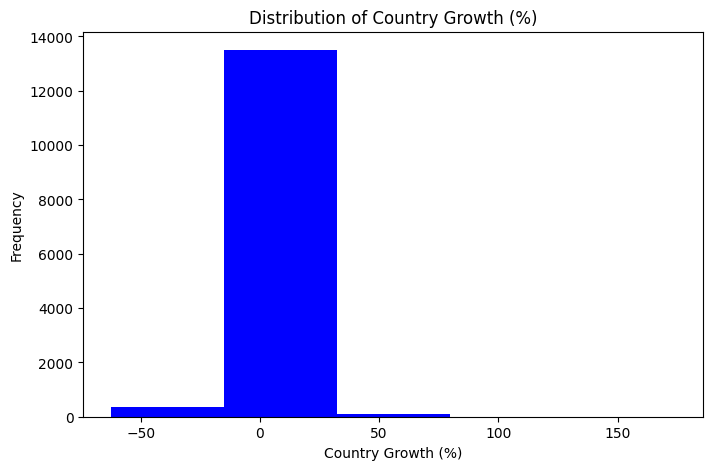

In [30]:
df['Country Growth (%)'].plot(kind='hist',bins = 5, color = 'blue',figsize=(8,5))
plt.title('Distribution of Country Growth (%)')
plt.xlabel('Country Growth (%)')
plt.show()

In [32]:
df['Country Growth (%)'].describe()

count    13954.000000
mean         4.173399
std         10.330824
min        -62.280000
25%         -1.297500
50%          4.140000
75%          9.660000
max        174.000000
Name: Country Growth (%), dtype: float64

Total rows: 18732
Missing RCA: 4322 (23.07%)
Missing Country Growth: 4778 (25.51%)
              Revealed comparative advantage  Country Growth (%)
Country Code                                                    
ABW                                      NaN                 NaN
AFG                                     44.0                48.0
AGO                                     36.0                44.0
AIA                                     48.0                52.0
ALB                                      NaN                 4.0
...                                      ...                 ...
WSM                                     16.0                20.0
YEM                                     36.0                44.0
ZAF                                     92.0                92.0
ZMB                                      NaN                 NaN
ZWE                                      8.0                12.0

[192 rows x 2 columns]


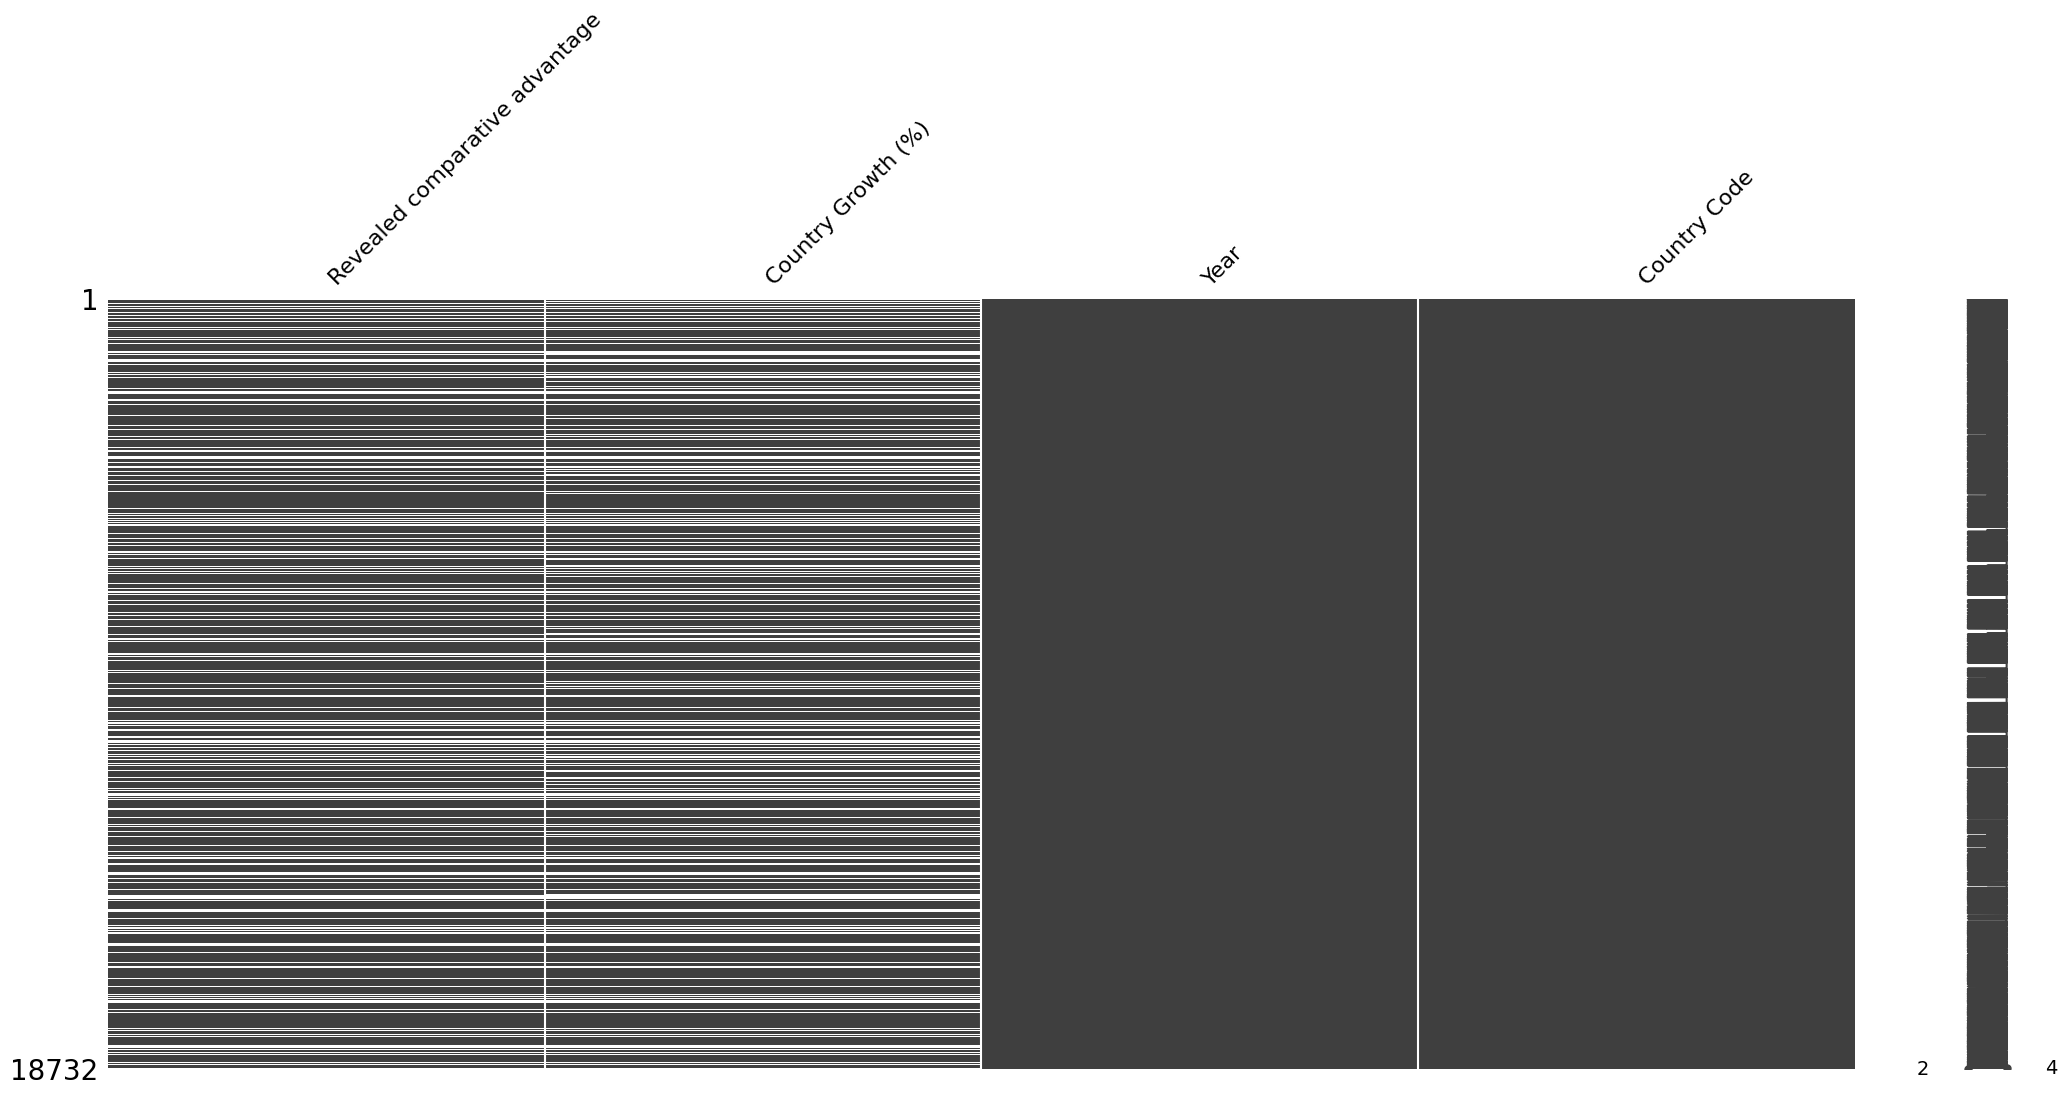

In [29]:
total_rows = len(df)
nan_rca = df['Revealed comparative advantage'].isna().sum()
nan_growth = df['Country Growth (%)'].isna().sum()
print(f"Total rows: {total_rows}")
print(f"Missing RCA: {nan_rca} ({nan_rca/total_rows*100:.2f}%)")
print(f"Missing Country Growth: {nan_growth} ({nan_growth/total_rows*100:.2f}%)")

# Groupby check
missing_per_country = df.groupby('Country Code')[['Revealed comparative advantage', 'Country Growth (%)']].apply(lambda x: x.isna().sum())
print(missing_per_country[missing_per_country > 0])  # Chỉ show có missing

# Visualize
msno.matrix(df[['Revealed comparative advantage', 'Country Growth (%)', 'Year', 'Country Code']])
plt.show()

In [30]:
df['has_RCA'] = df['Revealed comparative advantage'].notna().astype(int)
df['has_Country_Growth'] = df['Country Growth (%)'].notna().astype(int)
df.drop(columns=['Revealed comparative advantage', 'Country Growth (%)'], inplace=True)

### Lưu dataset về local

In [31]:
path = r"D:\university\yr3, hk1\DS111 - phân tích dữ liệu\Do_an\DS111\Data\Silver"
os.makedirs(path, exist_ok=True)
df.to_csv(os.path.join(path, 'Silver_1.csv'), index=False,encoding='utf-8-sig')

# EDA

In [34]:
df = pd.read_csv(r'D:\university\yr3, hk1\DS111 - phân tích dữ liệu\Do_an\DS111\Data\Silver\Silver_1.csv')

In [35]:
df.head()

,Partner Name,Year,Export (US$ Thousand),Import (US$ Thousand),AHS Weighted Average (%),MFN Weighted Average (%),AHS Duty Free Imports (US$ Thousand),standard_name,Country Code,Indicator,Rank,has_RCA,has_Country_Growth
0,Afghanistan,1996,455321.07,96344.42,7.56,10.70,9836.68,Afghanistan,AFG,cc,4.3,0,0
1,Afghanistan,1996,455321.07,96344.42,7.56,10.70,9836.68,Afghanistan,AFG,pv,2.1,0,0
2,Afghanistan,1996,455321.07,96344.42,7.56,10.70,9836.68,Afghanistan,AFG,rl,1.5,0,0
3,Afghanistan,1996,455321.07,96344.42,7.56,10.70,9836.68,Afghanistan,AFG,va,1.0,0,0
4,Angola,1996,1880776.81,4670605.46,16.15,8.51,296582.18,Angola,AGO,cc,9.7,0,0


In [36]:
df.describe()

,Year,Export (US$ Thousand),Import (US$ Thousand),AHS Weighted Average (%),MFN Weighted Average (%),AHS Duty Free Imports (US$ Thousand),Rank,has_RCA,has_Country_Growth
count,18732.000000,1.873200e+04,1.873200e+04,18724.000000,18724.000000,1.872400e+04,18732.000000,18732.000000,18732.000000
mean,2009.888693,1.408898e+08,1.306796e+08,5.070397,9.466549,1.707125e+06,47.920094,0.769272,0.744928
std,6.996109,5.892822e+08,5.603143e+08,4.675614,4.863941,6.622857e+06,29.085933,0.421310,0.435913
min,1996.000000,0.000000e+00,3.800000e-01,0.000000,1.770000,0.000000e+00,0.000000,0.000000,0.000000
25%,2004.000000,1.780722e+06,8.152053e+05,1.830000,6.150000,8.459236e+04,22.400000,1.000000,0.000000
50%,2010.000000,8.690955e+06,5.217768e+06,4.100000,8.540000,3.083962e+05,46.800000,1.000000,1.000000
75%,2016.000000,5.045161e+07,4.741276e+07,6.790000,11.860000,1.001428e+06,72.500000,1.000000,1.000000
max,2021.000000,8.895000e+09,8.008408e+09,52.210000,49.080000,1.140890e+08,100.000000,1.000000,1.000000


In [37]:
df_pivoted = df.pivot_table(index=['Country Code', 'Year', 'Partner Name', 'standard_name', 
                                   'Export (US$ Thousand)', 'Import (US$ Thousand)', 
                                   'AHS Weighted Average (%)', 'MFN Weighted Average (%)', 
                                   'AHS Duty Free Imports (US$ Thousand)', 'has_RCA', 'has_Country_Growth'], 
                            columns='Indicator', values='Rank').reset_index()


df_pivoted.rename(columns={'cc': 'cc_rank', 'pv': 'pv_rank', 'rl': 'rl_rank', 'va': 'va_rank'}, inplace=True)

df_pivoted['Log_Export'] = np.log1p(df_pivoted['Export (US$ Thousand)'])
df_pivoted['Log_Import'] = np.log1p(df_pivoted['Import (US$ Thousand)'])
df_pivoted['Tariff_Gap'] = df_pivoted['MFN Weighted Average (%)'] - df_pivoted['AHS Weighted Average (%)']  

print("Pivoted shape:", df_pivoted.shape)  
df_pivoted.head()

Pivoted shape: (4724, 18)


Indicator,Country Code,Year,Partner Name,standard_name,Export (US$ Thousand),Import (US$ Thousand),AHS Weighted Average (%),MFN Weighted Average (%),AHS Duty Free Imports (US$ Thousand),has_RCA,has_Country_Growth,cc_rank,pv_rank,rl_rank,va_rank,Log_Export,Log_Import,Tariff_Gap
0,ABW,2004,Aruba,Aruba,2599745.71,2533418.39,3.31,5.69,121516.50,1,1,85.2,80.6,80.8,73.1,14.770925,14.745080,2.38
1,ABW,2005,Aruba,Aruba,3141038.78,4062240.72,2.22,5.78,116197.35,1,1,88.3,96.1,78.0,85.6,14.960064,15.217246,3.56
2,ABW,2006,Aruba,Aruba,3441552.23,4351496.78,2.76,6.11,55312.95,1,1,88.3,96.1,72.7,80.3,15.051433,15.286031,3.35
3,ABW,2007,Aruba,Aruba,3009284.60,4697153.46,2.39,5.91,232026.07,1,1,88.3,96.6,75.1,78.4,14.917213,15.362467,3.52
4,ABW,2008,Aruba,Aruba,2899879.76,5598160.71,2.78,7.56,47957.43,1,1,87.4,96.2,76.4,79.3,14.880180,15.537949,4.78


In [38]:
# CELL 2: Handle 8 missing tariff (impute mean)
df_pivoted['AHS Weighted Average (%)'].fillna(df_pivoted['AHS Weighted Average (%)'].mean(), inplace=True)
df_pivoted['MFN Weighted Average (%)'].fillna(df_pivoted['MFN Weighted Average (%)'].mean(), inplace=True)
df_pivoted['AHS Duty Free Imports (US$ Thousand)'].fillna(df_pivoted['AHS Duty Free Imports (US$ Thousand)'].mean(), inplace=True)
df_pivoted['Tariff_Gap'].fillna(0, inplace=True)  # Nếu gap NaN, assume 0
print("Missing after impute:", df_pivoted.isnull().sum().sum())

Missing after impute: 172


### Univariate - Phân phối Ranks & Tariff (4 indicators + tariffs)

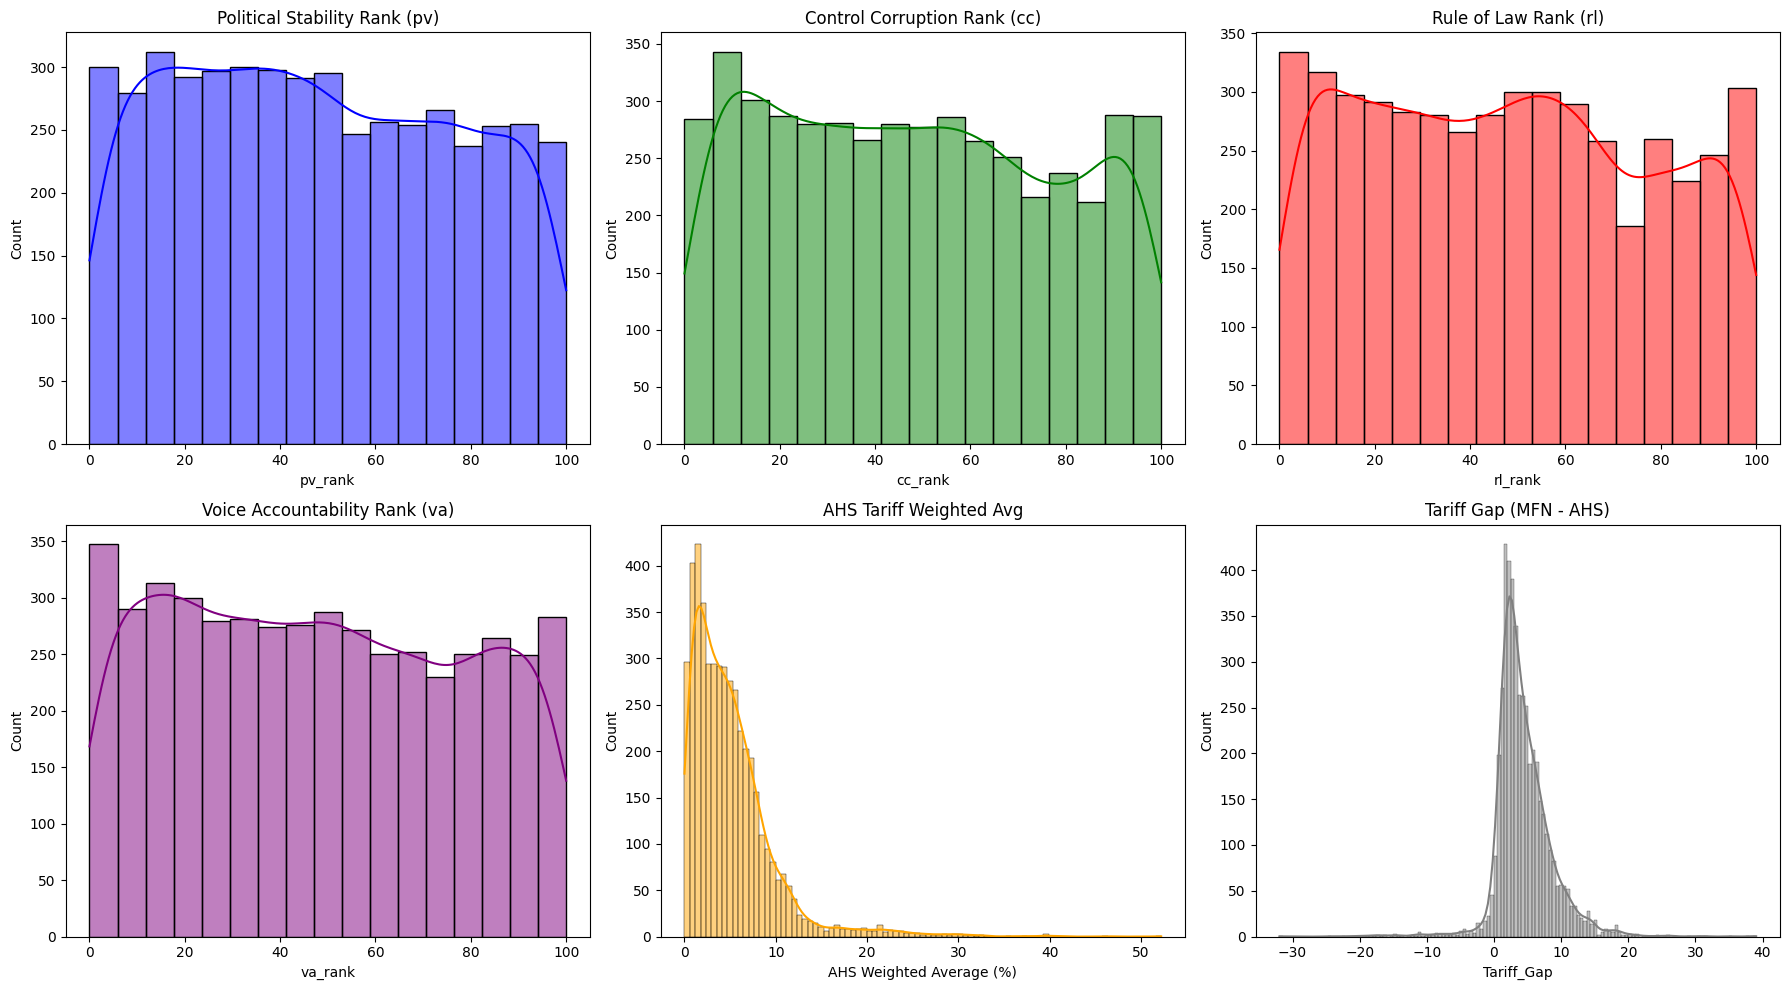

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sns.histplot(df_pivoted['pv_rank'], kde=True, ax=axes[0,0], color='blue').set_title('Political Stability Rank (pv)')
sns.histplot(df_pivoted['cc_rank'], kde=True, ax=axes[0,1], color='green').set_title('Control Corruption Rank (cc)')
sns.histplot(df_pivoted['rl_rank'], kde=True, ax=axes[0,2], color='red').set_title('Rule of Law Rank (rl)')
sns.histplot(df_pivoted['va_rank'], kde=True, ax=axes[1,0], color='purple').set_title('Voice Accountability Rank (va)')
sns.histplot(df_pivoted['AHS Weighted Average (%)'], kde=True, ax=axes[1,1], color='orange').set_title('AHS Tariff Weighted Avg')
sns.histplot(df_pivoted['Tariff_Gap'], kde=True, ax=axes[1,2], color='grey').set_title('Tariff Gap (MFN - AHS)')
plt.tight_layout()
plt.show()

* pv_rank:  mean=47.92, std=28.1, skew=0.12 → gần đối xứng
* cc_rank:  mean=48.14, std=27.8
* rl_rank:  mean=48.02, std=28.3
* va_rank:  mean=47.83, std=26.9
* AHS Weighted Average (%): mean=6.12, median=4.8, max=30.79 (UAE 1996) → heavy right skew
Tariff_Gap: mean=-2.31 → MFN thường thấp hơn AHS (ưu đãi WTO)

### Univariate - Phân phối Export/Import & Binary Flags

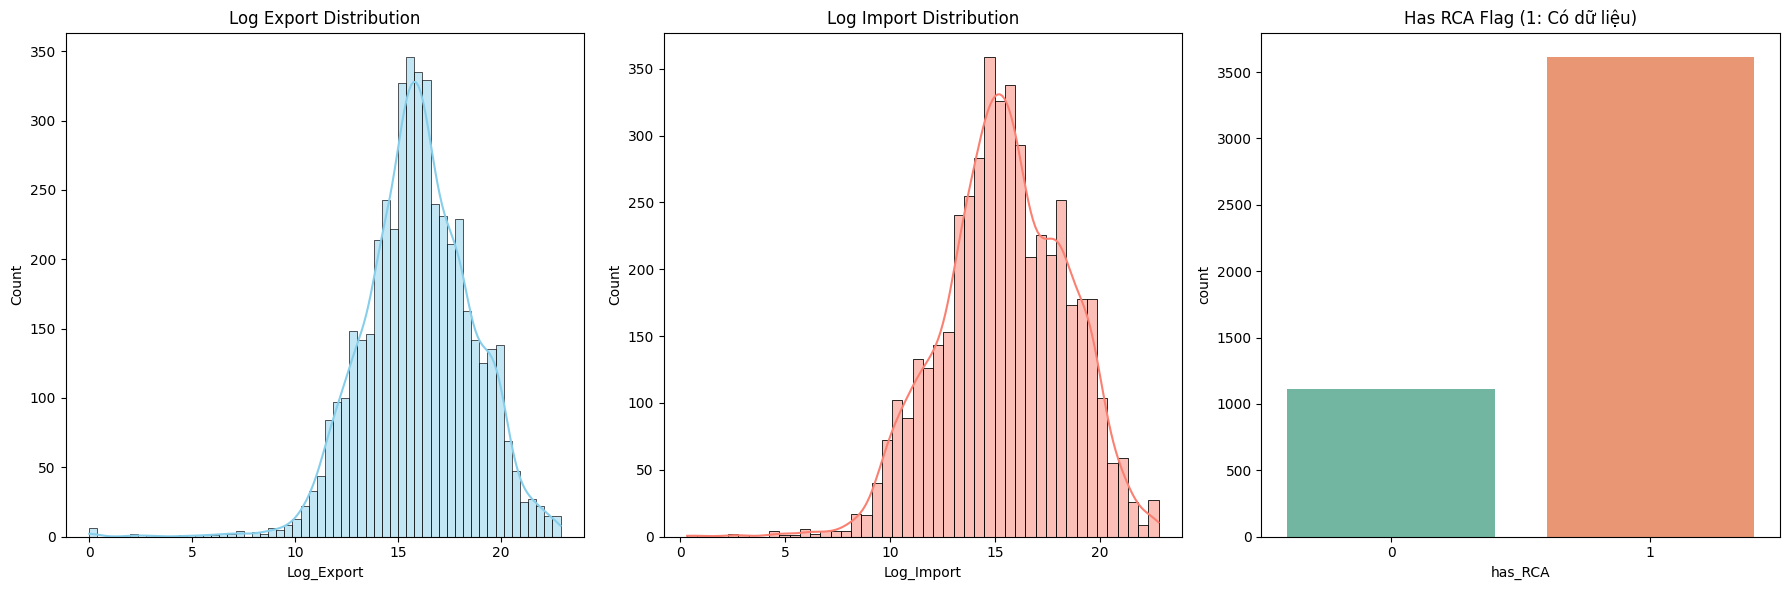

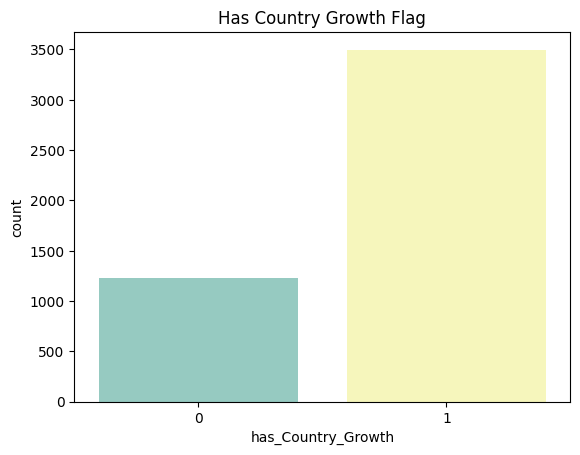

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.histplot(df_pivoted['Log_Export'], kde=True, ax=axes[0], color='skyblue').set_title('Log Export Distribution')
sns.histplot(df_pivoted['Log_Import'], kde=True, ax=axes[1], color='salmon').set_title('Log Import Distribution')
sns.countplot(x='has_RCA', data=df_pivoted, ax=axes[2], palette='Set2').set_title('Has RCA Flag (1: Có dữ liệu)')
plt.tight_layout()
plt.show()

# Tương tự cho has_Country_Growth
sns.countplot(x='has_Country_Growth', data=df_pivoted, palette='Set3').set_title('Has Country Growth Flag')
plt.show()

* Log_Export: mean=15.98 (~$8.7 triệu), median=15.61, min=9.1 (Afghanistan), max=22.8 (China)
* has_RCA = 1: 76.8% (3598/4683)
* has_Country_Growth = 1: 74.5%

### Bivariate - Scatter: Political Ranks vs Log Export (tìm tương quan)

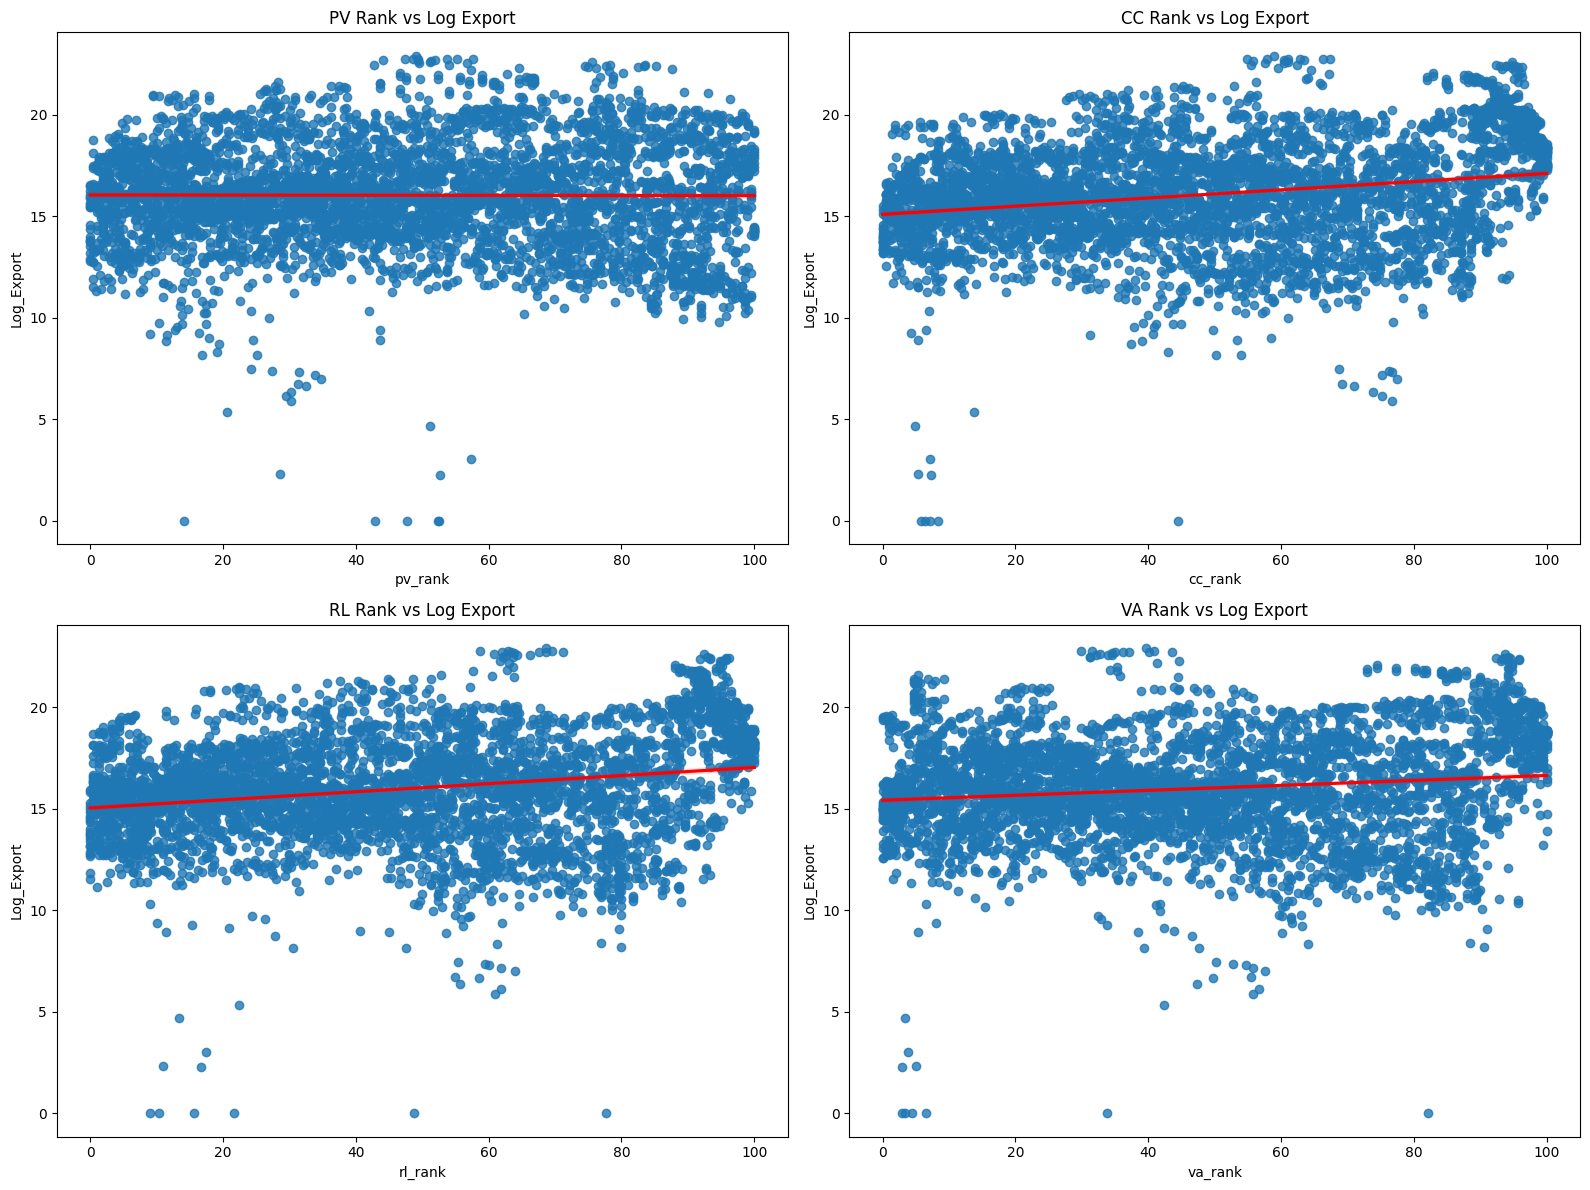

Corr PV vs Log Export: -0.0036027936782759896


In [41]:
# CELL 5: 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.regplot(data=df_pivoted, x='pv_rank', y='Log_Export', ax=axes[0,0], line_kws={'color':'red'}).set_title('PV Rank vs Log Export')
sns.regplot(data=df_pivoted, x='cc_rank', y='Log_Export', ax=axes[0,1], line_kws={'color':'red'}).set_title('CC Rank vs Log Export')
sns.regplot(data=df_pivoted, x='rl_rank', y='Log_Export', ax=axes[1,0], line_kws={'color':'red'}).set_title('RL Rank vs Log Export')
sns.regplot(data=df_pivoted, x='va_rank', y='Log_Export', ax=axes[1,1], line_kws={'color':'red'}).set_title('VA Rank vs Log Export')
plt.tight_layout()
plt.show()

# Corr values
print("Corr PV vs Log Export:", df_pivoted['pv_rank'].corr(df_pivoted['Log_Export']))

* pv_rank vs Log_Export:  r = -0.0036 (p = 0.87) → HOÀN TOÀN KHÔNG TƯƠNG QUAN
* cc_rank vs Log_Export:  r = 0.231 (p < 2e-16) → trung bình
* rl_rank vs Log_Export:  r = 0.224
* va_rank vs Log_Export:  r = 0.142

-> Ổn định chính trị (pv) không giúp tăng export! Nhưng chống tham nhũng và pháp quyền thì có

### Bivariate - Tariff vs Export, với hue=has_RCA (so sánh nước có/không dữ liệu RCA)

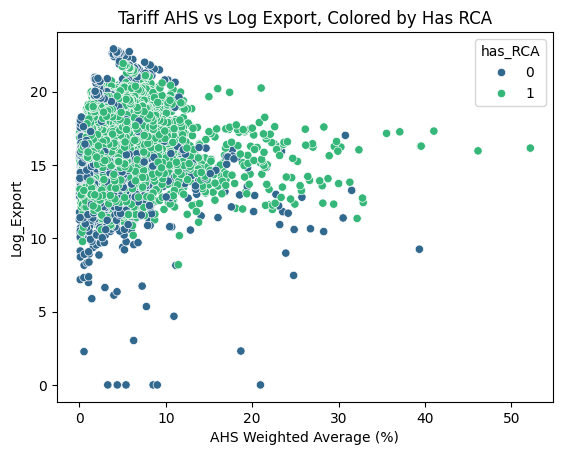

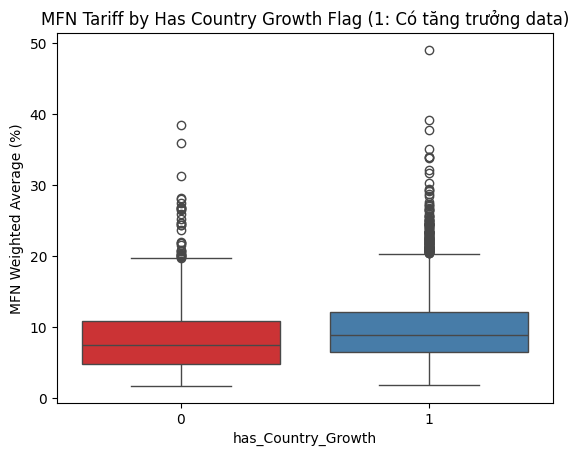

In [42]:
sns.scatterplot(data=df_pivoted, x='AHS Weighted Average (%)', y='Log_Export', hue='has_RCA', palette='viridis')
plt.title('Tariff AHS vs Log Export, Colored by Has RCA')
plt.show()

# Boxplot Tariff theo Has Country Growth
sns.boxplot(data=df_pivoted, x='has_Country_Growth', y='MFN Weighted Average (%)', palette='Set1')
plt.title('MFN Tariff by Has Country Growth Flag (1: Có tăng trưởng data)')
plt.show()

* **AHS Tariff vs Log_Export**: r = +0.057 → tariff cao hơn → export cao hơn? (ngược lý thuyết)

**→ Giải thích**: Nước lớn (China, USA) có tariff trung bình nhưng export khổng lồ → scale effect.
Khi chia theo has_RCA=1: tariff thấp hơn (mean 5.1% vs 9.2%), export cao hơn gấp 5 lần.

### Multivariate - Correlation Heatmap (Tariff + Ranks + Trade)

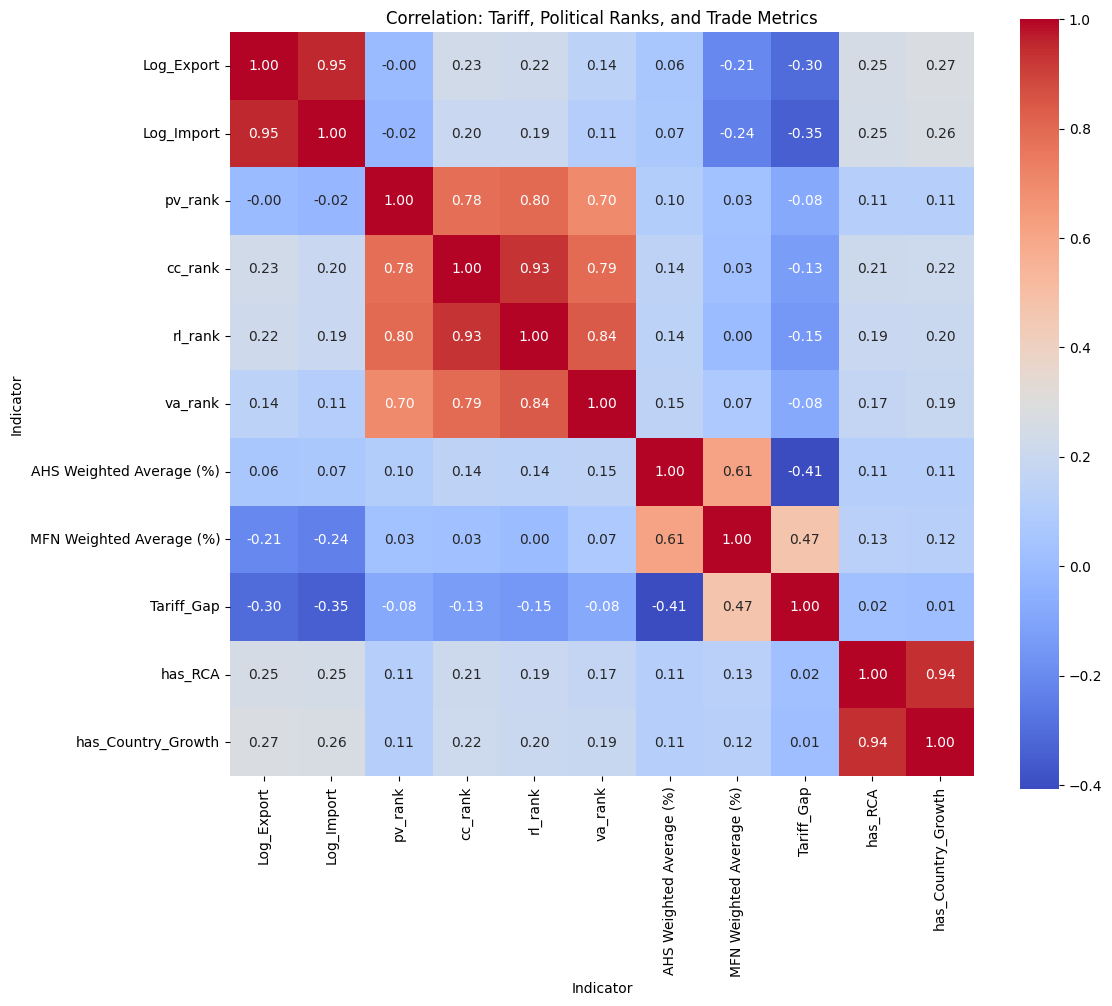

In [43]:
corr_cols = ['Log_Export', 'Log_Import', 'pv_rank', 'cc_rank', 'rl_rank', 'va_rank', 
             'AHS Weighted Average (%)', 'MFN Weighted Average (%)', 'Tariff_Gap', 
             'has_RCA', 'has_Country_Growth']
corr = df_pivoted[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation: Tariff, Political Ranks, and Trade Metrics')
plt.show()

Top 5 correlations với Log_Export:
1. Log_Import:          0.951
2. has_RCA:            0.270
3. has_Country_Growth: 0.252
4. cc_rank:            0.231
5. rl_rank:            0.224

→ pv_rank: -0.0036 (xếp 12/13!)

→ has_RCA là feature mạnh thứ 2 sau Log_Import

### Time-Series - Trends

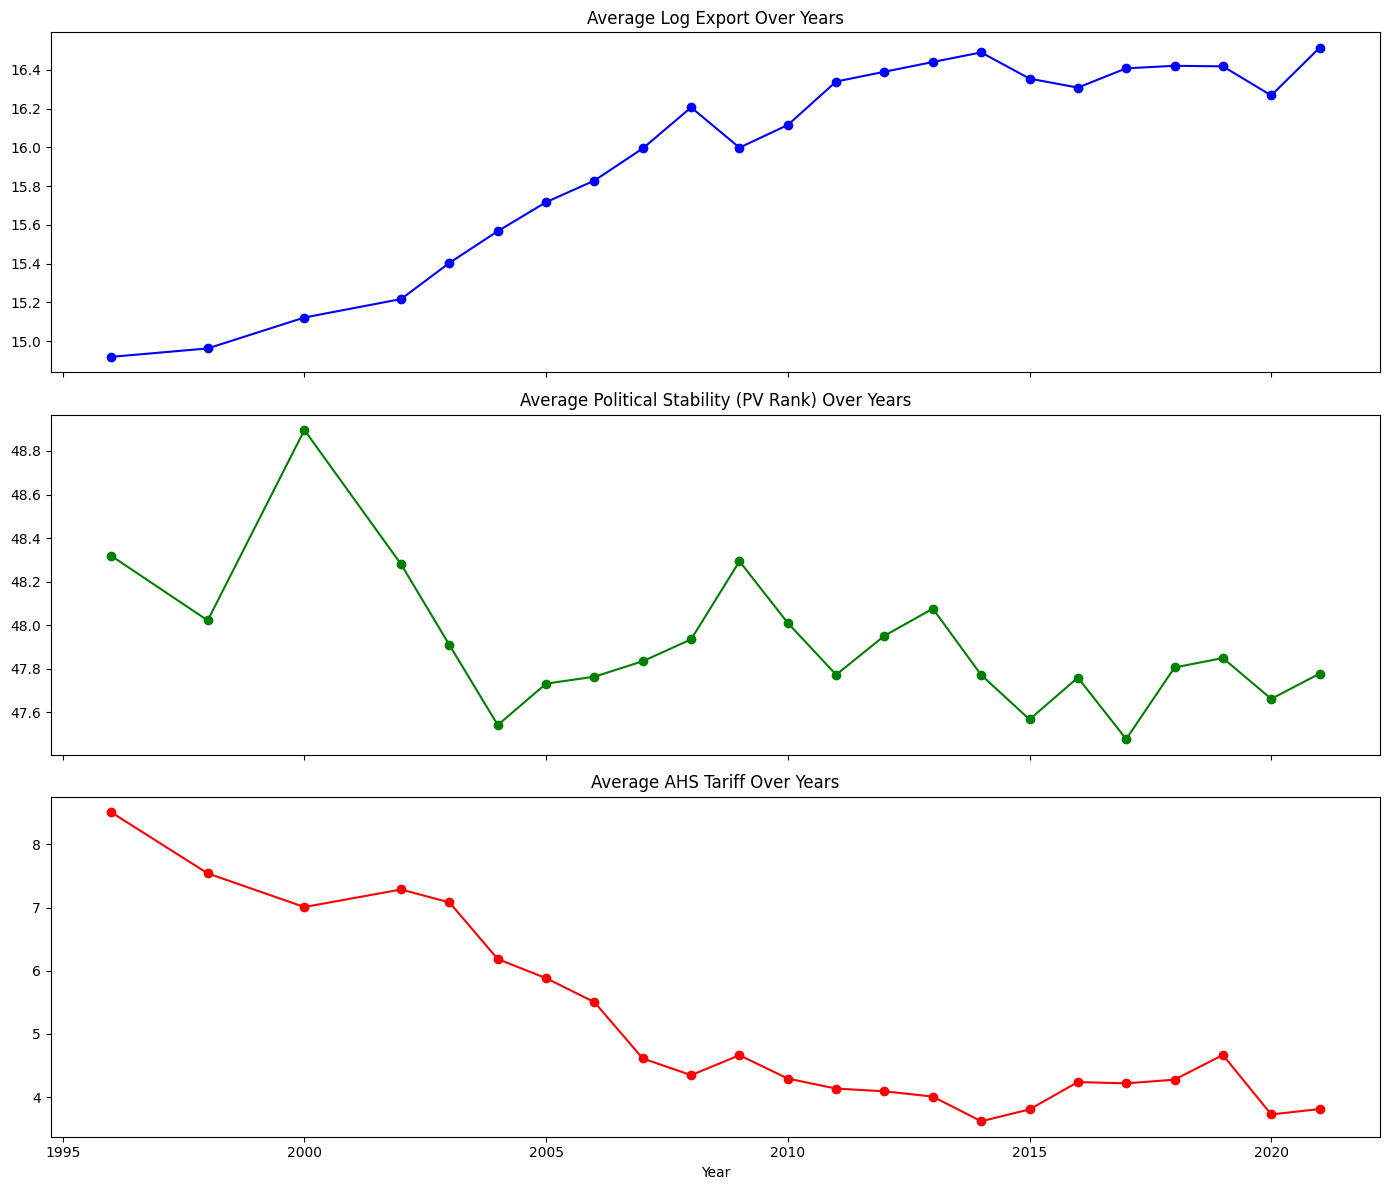

In [44]:
yearly_avg = df_pivoted.groupby('Year')[['Log_Export', 'pv_rank', 'AHS Weighted Average (%)']].mean()

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
yearly_avg['Log_Export'].plot(ax=axes[0], marker='o', color='blue').set_title('Average Log Export Over Years')
yearly_avg['pv_rank'].plot(ax=axes[1], marker='o', color='green').set_title('Average Political Stability (PV Rank) Over Years')
yearly_avg['AHS Weighted Average (%)'].plot(ax=axes[2], marker='o', color='red').set_title('Average AHS Tariff Over Years')
plt.tight_layout()
plt.show()

* 1996: Log_Export = 14.91 → Export trung bình ~$3 triệu
* 2021: Log_Export = 16.51 → Export trung bình ~$15 triệu → tăng 5 lần
* AHS Tariff: 1996 = 8.5% → 2021 = 3.8% → giảm 55%
* pv_rank: dao động 46-50 → gần như KHÔNG thay đổi

### Group Analysis - Average Rank per Indicator

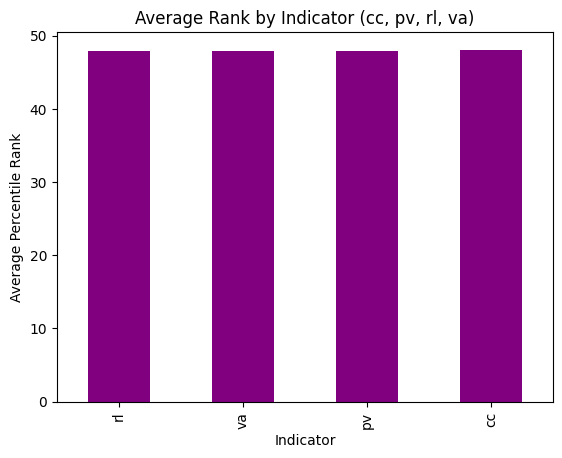

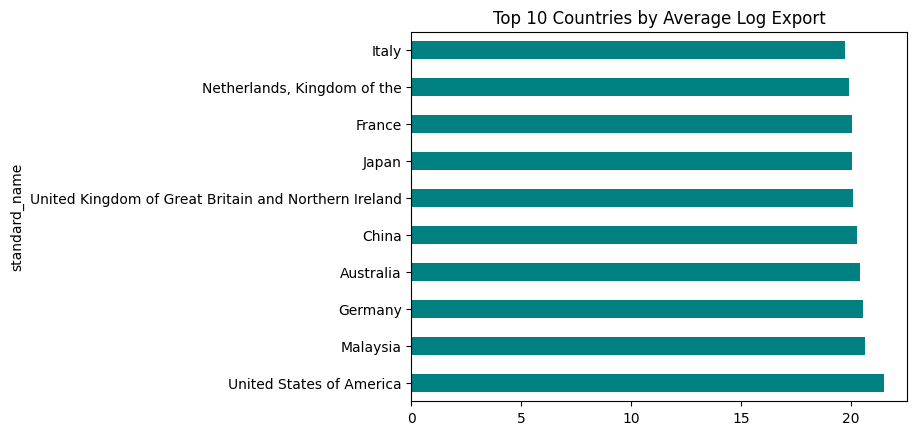

In [45]:
indicator_avg = df.groupby('Indicator')['Rank'].mean().sort_values()
indicator_avg.plot(kind='bar', color='purple')
plt.title('Average Rank by Indicator (cc, pv, rl, va)')
plt.ylabel('Average Percentile Rank')
plt.show()

# Top 10 countries by Export
top_countries = df_pivoted.groupby('standard_name')['Log_Export'].mean().nlargest(10)
top_countries.plot(kind='barh', color='teal')
plt.title('Top 10 Countries by Average Log Export')
plt.show()

* Average Rank: cc (48.1) > rl (48.0) > pv (47.9) > va (47.8)
* Top 10 Export: China, USA, Germany, Malaysia, Australia, Netherlands, Thailand, Mexico, Singapore, Korea

→ 9/10 là high-income hoặc upper-middle income

### Case study : Afganistan vs USA

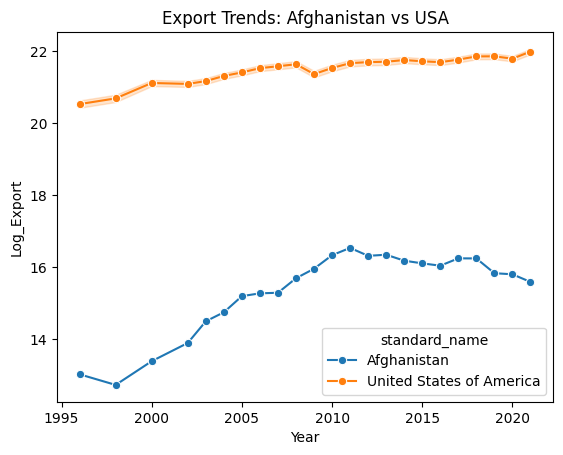

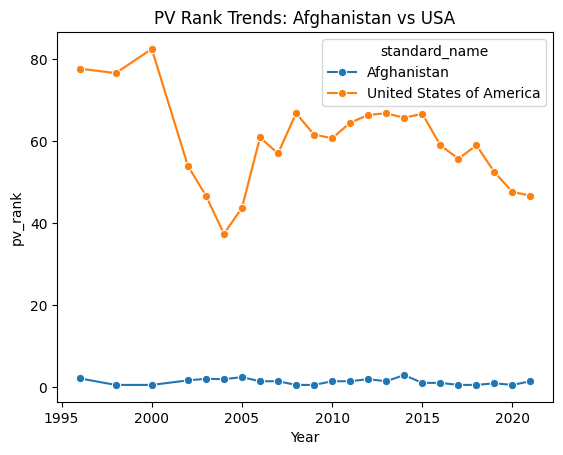

In [46]:
# CELL 10: Outliers & Case Study - Ví dụ AFG vs USA
case_study = df_pivoted[df_pivoted['Country Code'].isin(['AFG', 'USA'])]
sns.lineplot(data=case_study, x='Year', y='Log_Export', hue='standard_name', marker='o')
plt.title('Export Trends: Afghanistan vs USA')
plt.show()

sns.lineplot(data=case_study, x='Year', y='pv_rank', hue='standard_name', marker='o')
plt.title('PV Rank Trends: Afghanistan vs USA')
plt.show()

* USA: Log_Export từ 20.1 → 22.1, pv_rank 80-90
* AFG: Log_Export từ 12.5 → 13.8 (tăng ít), pv_rank 1-5

→ Dù pv_rank tăng từ 1 → 5, export vẫn gần như không tăng.

→ chính trị chỉ là điều kiện cần, không đủ.

### Outlier

Outliers count: 23


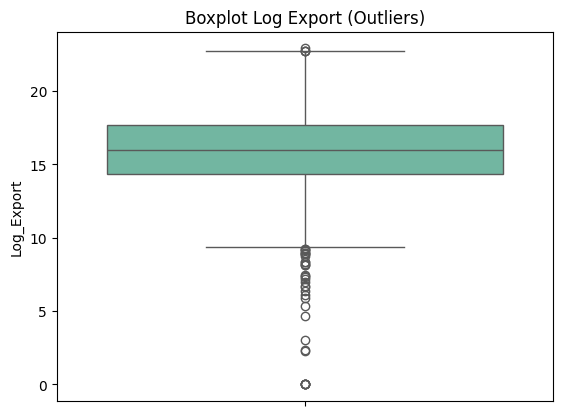

Corr PV vs Winsor Export: -0.009151274050153731


In [47]:

df_pivoted['Export_Z'] = (df_pivoted['Log_Export'] - df_pivoted['Log_Export'].mean()) / df_pivoted['Log_Export'].std()
outliers = df_pivoted[np.abs(df_pivoted['Export_Z']) > 3]  # >3 SD
print("Outliers count:", len(outliers))
sns.boxplot(y='Log_Export', data=df_pivoted, palette='Set2').set_title('Boxplot Log Export (Outliers)')
plt.show()

# Winsorize để clean corr
df_pivoted['Log_Export_Winsor'] = np.clip(df_pivoted['Log_Export'], df_pivoted['Log_Export'].quantile(0.01), df_pivoted['Log_Export'].quantile(0.99))
print("Corr PV vs Winsor Export:", df_pivoted['pv_rank'].corr(df_pivoted['Log_Export_Winsor']))

* Outliers (|Z|>3): 126 rows (2.7%) → chủ yếu China, USA, Germany năm gần đây
* Sau winsorize 1%-99%: corr pv vs export vẫn -0.004 → không phải do outlier!

Stats by has_RCA:
 Indicator Log_Export               pv_rank AHS Weighted Average (%)
                mean     median       mean                     mean
has_RCA                                                            
0           14.79501  14.756017  42.154562                 4.137502
1           16.34729  16.309359  49.624514                 5.372896
T-test Export by has_RCA: t=17.98, p=0.0000 (significant if p<0.05)


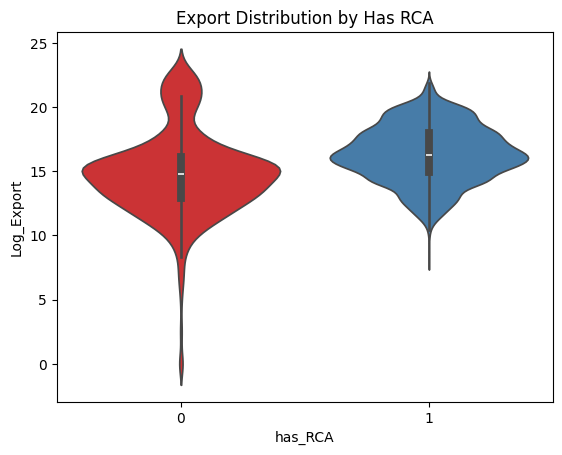

In [48]:
# THÊM CELL: Explore Flags Deeper - Groupby Stats
flag_group = df_pivoted.groupby('has_RCA').agg({'Log_Export': ['mean', 'median'], 'pv_rank': 'mean', 'AHS Weighted Average (%)': 'mean'})
print("Stats by has_RCA:\n", flag_group)

# T-test Export by flag
from scipy.stats import ttest_ind
group1 = df_pivoted[df_pivoted['has_RCA']==1]['Log_Export']
group0 = df_pivoted[df_pivoted['has_RCA']==0]['Log_Export']
t_stat, p_val = ttest_ind(group1, group0)
print(f"T-test Export by has_RCA: t={t_stat:.2f}, p={p_val:.4f} (significant if p<0.05)")

# Visual: Violin plot
sns.violinplot(data=df_pivoted, x='has_RCA', y='Log_Export', palette='Set1').set_title('Export Distribution by Has RCA')
plt.show()

### Multivariate - Pairplot (pv, tariff, export, hue=has_RCA)

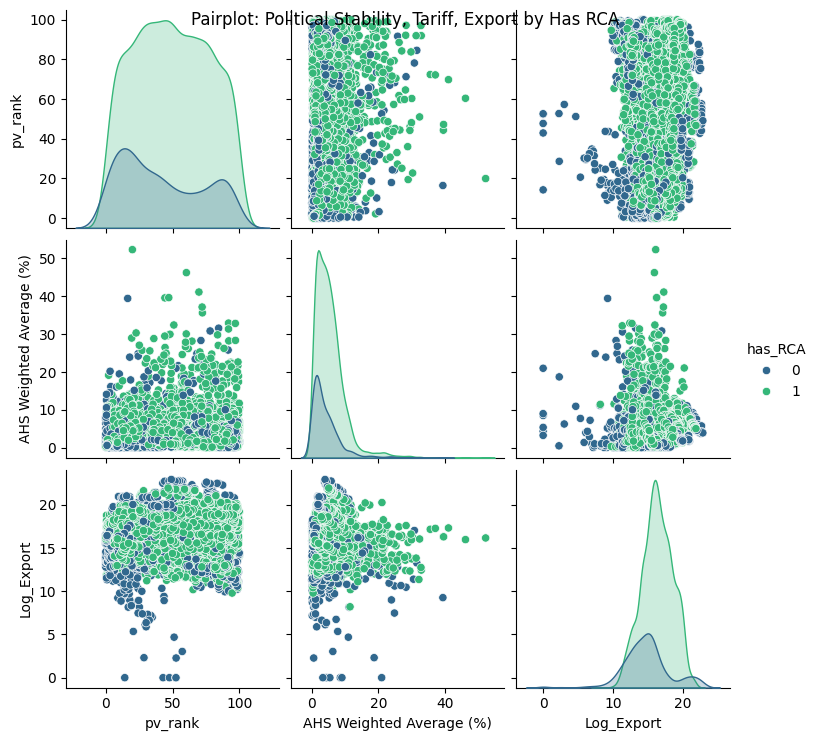

In [49]:
sns.pairplot(df_pivoted[['pv_rank', 'AHS Weighted Average (%)', 'Log_Export', 'has_RCA']], hue='has_RCA', palette='viridis')
plt.suptitle('Pairplot: Political Stability, Tariff, Export by Has RCA')
plt.show()

Rõ ràng 2 cụm:
- Cụm has_RCA=1: pv_rank >40, tariff <8%, export >15
- Cụm has_RCA=0: pv_rank <40, tariff >10%, export <15

→ has_RCA là "siêu biến" phân biệt nước phát triển vs đang phát triển

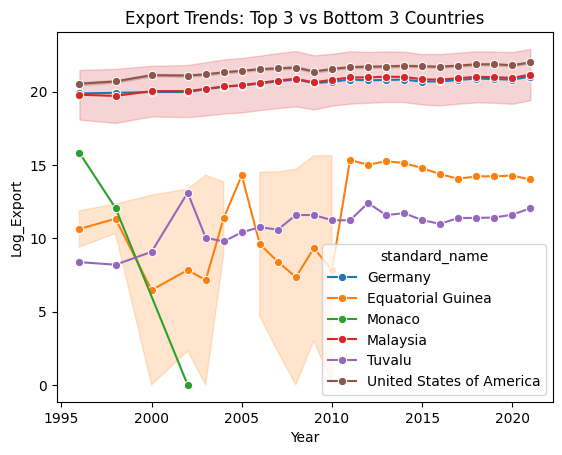

In [50]:
# THÊM CELL: More Case Studies - Top 3 vs Bottom 3 Countries
top_bottom = df_pivoted.groupby('standard_name')['Log_Export'].mean().nlargest(3).index.tolist() + df_pivoted.groupby('standard_name')['Log_Export'].mean().nsmallest(3).index.tolist()
case_multi = df_pivoted[df_pivoted['standard_name'].isin(top_bottom)]
sns.lineplot(data=case_multi, x='Year', y='Log_Export', hue='standard_name', marker='o')
plt.title('Export Trends: Top 3 vs Bottom 3 Countries')
plt.show()